# =================================================================
# SECTION A: IMPORTING LIBRARIES
# =================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
import yfinance as yf
from datetime import timedelta
from scipy.stats import gaussian_kde

start = time.time()

PATH = os.path.join(os.getcwd(), "output")
os.makedirs(PATH, exist_ok=True)

# =================================================================
# SECTION B: DATA_EXPLORATION
# =================================================================

In [2]:
print("<----------DATA_EXPLORATION---------->")

nifty_raw = yf.download("^NSEI", start="2016-01-01", end="2026-01-01", interval="1wk", progress=False, auto_adjust=True)

data = pd.DataFrame(nifty_raw)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns]
data = data.reset_index()

if 'Price' in data.columns:
    data.rename(columns={'Price': 'Date'}, inplace=True)

data.to_csv(os.path.join(PATH, "Nifty50_raw.csv"), index=False)
print("Raw CSV file saved successfully")

print("First 10 Rows\n", data.head(10))
print("Last 10 Rows\n", data.tail(10))
print("Info\n"); data.info()
print("Describe\n", data.describe())
print("Shape:", data.shape)
print("Size:", data.size)
print("Columns:", data.columns)
print("Null Sum:\n", data.isnull().sum())
print("Total Nulls:", data.isnull().sum().sum())
print("Null %:\n", data.isnull().mean() * 100)
print("Total Null %:", (data.isnull().sum().sum() / data.size) * 100)
print("Duplicates Sum:", data.duplicated().sum())
print("Unique Values:\n", data.nunique())

<----------DATA_EXPLORATION---------->
Raw CSV file saved successfully
First 10 Rows
         Date        Close         High          Low         Open   Volume
0 2016-01-04  7601.350098  7937.549805  7556.600098  7924.549805   773300
1 2016-01-11  7437.799805  7605.100098  7425.799805  7527.450195   966400
2 2016-01-18  7422.450195  7470.899902  7241.500000  7420.350098  1117400
3 2016-01-25  7563.549805  7575.649902  7402.799805  7468.750000   924000
4 2016-02-01  7489.100098  7600.450195  7350.299805  7589.500000  1095100
5 2016-02-08  6980.950195  7512.549805  6869.000000  7489.700195  1256700
6 2016-02-15  7210.750000  7226.850098  6960.649902  7057.350098  1307000
7 2016-02-22  7029.750000  7252.399902  6961.399902  7208.850098  1038300
8 2016-02-29  7485.350098  7505.899902  6825.799805  7050.450195  1647300
9 2016-03-07  7510.200195  7547.100098  7424.299805  7486.399902   925500
Last 10 Rows
           Date         Close          High           Low          Open  \
512 2025-10-

# =================================================================
# SECTION C: DATA_CLEANING
# =================================================================

In [3]:
print("<----------DATA_CLEANING---------->")

data.drop_duplicates(inplace=True)
data.dropna(subset=['Date'], inplace=True)
data.reset_index(drop=True, inplace=True)
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

for col in ['Open', 'High', 'Low', 'Close']:
    data[col] = data[col].astype('float32')

data['Volume'] = data['Volume'].fillna(0).astype('int64')
data[['Open', 'High', 'Low', 'Close']] = data[['Open', 'High', 'Low', 'Close']].ffill()

print("<--- Dataset Summary after Cleaning --->")
data.info()

<----------DATA_CLEANING---------->
<--- Dataset Summary after Cleaning --->
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    522 non-null    datetime64[ns]
 1   Close   522 non-null    float32       
 2   High    522 non-null    float32       
 3   Low     522 non-null    float32       
 4   Open    522 non-null    float32       
 5   Volume  522 non-null    int64         
dtypes: datetime64[ns](1), float32(4), int64(1)
memory usage: 16.4 KB


# =================================================================
# SECTION D: SAVING PROCESSED FILES
# =================================================================

In [4]:
data.to_csv(os.path.join(PATH, "Nifty50_cleaned.csv"), index=False)
print("Cleaned CSV saved successfully")

Cleaned CSV saved successfully


# =================================================================
# SECTION E: CREATING DATA SUBSET
# =================================================================

In [5]:
sub_set = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

for col in ['Open', 'High', 'Low', 'Close']:
    sub_set[col] = sub_set[col].astype('float64')

sub_set = sub_set.sort_values('Date').reset_index(drop=True)
sub_set['Weekly_Return_%'] = sub_set['Close'].pct_change() * 100
sub_set['Weekly_Return_%'] = sub_set['Weekly_Return_%'].round(2)
sub_set['Year'] = sub_set['Date'].dt.year
sub_set['Month'] = sub_set['Date'].dt.month
sub_set['MA_50'] = sub_set['Close'].rolling(window=50).mean()
sub_set['MA_200'] = sub_set['Close'].rolling(window=200).mean()
sub_set['Month_Name'] = sub_set['Date'].dt.strftime('%b')

print(sub_set.head())
sub_set.to_csv(os.path.join(PATH, "Nifty50_SubSet.csv"), index=False)
print("SubSet CSV saved successfully")

        Date         Open         High          Low        Close   Volume  \
0 2016-01-04  7924.549805  7937.549805  7556.600098  7601.350098   773300   
1 2016-01-11  7527.450195  7605.100098  7425.799805  7437.799805   966400   
2 2016-01-18  7420.350098  7470.899902  7241.500000  7422.450195  1117400   
3 2016-01-25  7468.750000  7575.649902  7402.799805  7563.549805   924000   
4 2016-02-01  7589.500000  7600.450195  7350.299805  7489.100098  1095100   

   Weekly_Return_%  Year  Month  MA_50  MA_200 Month_Name  
0              NaN  2016      1    NaN     NaN        Jan  
1            -2.15  2016      1    NaN     NaN        Jan  
2            -0.21  2016      1    NaN     NaN        Jan  
3             1.90  2016      1    NaN     NaN        Jan  
4            -0.98  2016      2    NaN     NaN        Feb  
SubSet CSV saved successfully


# =================================================================
# SECTION F: INSIGHTS_OF_THE_DATA_SET
# =================================================================

In [6]:
print("<----------INSIGHTS---------->")

worst_weeks = sub_set.dropna(subset=['Weekly_Return_%']).sort_values(by='Weekly_Return_%').head(3)
print("\n--- 1. Top 3 Biggest Market Crashes ---")
print(worst_weeks[['Date', 'Close', 'Weekly_Return_%']])

best_weeks = sub_set.dropna(subset=['Weekly_Return_%']).sort_values(by='Weekly_Return_%', ascending=False).head(3)
print("\n--- 2. Top 3 Biggest Market Jumps ---")
print(best_weeks[['Date', 'Close', 'Weekly_Return_%']])

start_price = sub_set['Close'].iloc[0]
end_price = sub_set['Close'].iloc[-1]
total_growth = ((end_price - start_price) / start_price) * 100
print("\n--- 3. Total 10-Year Growth ---")
print("Start Price (2016):", round(start_price, 2))
print("End Price (2026):", round(end_price, 2))
print("Total Growth (%):", round(total_growth, 2))

rolling_max = sub_set['Close'].cummax()
drawdown = (sub_set['Close'] - rolling_max) / rolling_max * 100
max_drawdown = drawdown.min()
max_drawdown_date = sub_set.loc[drawdown.idxmin(), 'Date']
print("\n--- 4. Maximum Drawdown ---")
print("Max Drawdown (%):", round(max_drawdown, 2))
print("Date of Max Drawdown:", max_drawdown_date)

monthly_avg = sub_set.groupby('Month')['Weekly_Return_%'].mean().reset_index()
monthly_avg['Month_Name'] = pd.to_datetime(monthly_avg['Month'], format='%m').dt.strftime('%b')
monthly_avg = monthly_avg.sort_values('Month')
best_month = monthly_avg.loc[monthly_avg['Weekly_Return_%'].idxmax(), 'Month_Name']
worst_month = monthly_avg.loc[monthly_avg['Weekly_Return_%'].idxmin(), 'Month_Name']
print("\n--- 5. Monthly Seasonality ---")
print("Best Month:", best_month)
print("Worst Month:", worst_month)

risk_free_weekly = 6.0 / 52
clean_returns = sub_set['Weekly_Return_%'].dropna()
excess_returns = clean_returns - risk_free_weekly
sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * np.sqrt(52)
print("\n--- 6. Sharpe Ratio ---")
print("Sharpe Ratio:", round(sharpe_ratio, 4))

annualized_volatility = clean_returns.std() * np.sqrt(52)
print("\n--- 6b. Annualized Volatility ---")
print("Annualized Volatility (%):", round(annualized_volatility, 2))

yearly_summary = sub_set.groupby('Year').agg(
    Avg_Close=('Close', 'mean'),
    Avg_Return=('Weekly_Return_%', 'mean'),
    Total_Volume=('Volume', 'sum')
).reset_index()
print("\n--- Yearly Summary ---")
print(yearly_summary)

<----------INSIGHTS---------->

--- 1. Top 3 Biggest Market Crashes ---
          Date         Close  Weekly_Return_%
219 2020-03-16   8745.450195           -12.15
218 2020-03-09   9955.200195            -9.41
216 2020-02-24  11201.750000            -7.28

--- 2. Top 3 Biggest Market Jumps ---
          Date         Close  Weekly_Return_%
222 2020-04-06   9111.900391            12.72
265 2021-02-01  14924.250000             9.46
225 2020-04-27   9859.900391             7.71

--- 3. Total 10-Year Growth ---
Start Price (2016): 7601.35
End Price (2026): 26146.55
Total Growth (%): 243.97

--- 4. Maximum Drawdown ---
Max Drawdown (%): -34.56
Date of Max Drawdown: 2020-03-30 00:00:00

--- 5. Monthly Seasonality ---
Best Month: Apr
Worst Month: Feb

--- 6. Sharpe Ratio ---
Sharpe Ratio: 0.487

--- 6b. Annualized Volatility ---
Annualized Volatility (%): 15.48

--- Yearly Summary ---
   Year     Avg_Close  Avg_Return  Total_Volume
0  2016   8096.165415    0.169020      47772400
1  2017   9600

# =================================================================
# SECTION G: DATA_VISUALISATION
# =================================================================

In [7]:
def plot_pro_bar(df, x_col="Date", y_col="Weekly_Return_%", title="Nifty 50: Weekly Volatility & Market Crashes (2016–2026)"):
    sns.set_theme(
        context='talk',
        style='dark',
        rc={"axes.spines.right": False, "axes.spines.top": False,
            "figure.facecolor": "#0d1117", "axes.facecolor": "#0d1117",
            "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"}
    )
    plt.rcParams['figure.dpi'] = 100

    fig, ax = plt.subplots(figsize=(16, 7), dpi=100)
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#0d1117')

    colors = ['#ff4d4d' if val < 0 else '#00e676' for val in df[y_col]]
    ax.bar(df[x_col], df[y_col], color=colors, width=timedelta(days=5), alpha=0.9)

    min_idx = df[y_col].idxmin()
    crash_val = df.loc[min_idx, y_col]
    crash_date = df.loc[min_idx, x_col]
    ax.annotate(
        f'Biggest Crash\n{crash_val:.2f}%',
        xy=(crash_date, crash_val),
        xytext=(30, -45),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='#ff4d4d', lw=1.8),
        fontsize=10, fontweight='bold', color='#ff4d4d'
    )

    max_idx = df[y_col].idxmax()
    jump_val = df.loc[max_idx, y_col]
    jump_date = df.loc[max_idx, x_col]
    ax.annotate(
        f'Biggest Jump\n{jump_val:.2f}%',
        xy=(jump_date, jump_val),
        xytext=(30, 30),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='#00e676', lw=1.8),
        fontsize=10, fontweight='bold', color='#00e676'
    )

    ax.axhline(0, color='white', linewidth=1.2, alpha=0.6)
    avg_val = df[y_col].mean()
    ax.axhline(avg_val, color='#ffd700', linestyle='--', linewidth=1.5,
               alpha=0.8, label=f'Avg Return: {avg_val:.2f}%')

    ax.set_title(title, loc='left', fontsize=20, pad=20, fontweight='bold', color='white')
    ax.set_xlabel("Timeline (Years)", fontsize=13, labelpad=10, color='white')
    ax.set_ylabel("Weekly Return (%)", fontsize=13, labelpad=10, color='white')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, labelcolor='white')
    ax.grid(axis='y', linestyle='-', alpha=0.08, color='white')

    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "nifty50_weekly_volatility_bar.png"), dpi=500, transparent=False, bbox_inches="tight")
    print("Chart saved: nifty50_weekly_volatility_bar.png")
    plt.show()
    plt.close()


def plot_pro_line(df, x_col="Date", y_col="Close", title="Nifty 50: 10-Year Wealth Creation Trend (2016–2026)"):
    sns.set_theme(
        context='talk',
        style='white',
        rc={"axes.spines.right": False, "axes.spines.top": False}
    )
    plt.rcParams['figure.dpi'] = 100

    fig, ax = plt.subplots(figsize=(16, 7), dpi=100)
    df_plot = df.dropna(subset=[y_col]).copy()

    ax.fill_between(df_plot[x_col], df_plot[y_col], alpha=0.12, color='#1a73e8')
    sns.lineplot(data=df_plot, x=x_col, y=y_col, linewidth=2.5, color='#1a73e8', ax=ax)

    max_idx = df_plot[y_col].idxmax()
    peak_val = df_plot.loc[max_idx, y_col]
    peak_x = df_plot.loc[max_idx, x_col]
    ax.annotate(
        f'All-Time High\n{peak_val:,.0f}',
        xy=(peak_x, peak_val),
        xytext=(-90, -35),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='#e53935', lw=1.8),
        fontsize=11, fontweight='bold', color='#e53935'
    )

    covid_start = pd.Timestamp('2020-01-01')
    covid_end = pd.Timestamp('2020-06-01')
    covid_data = df_plot[(df_plot[x_col] >= covid_start) & (df_plot[x_col] <= covid_end)]
    if not covid_data.empty:
        covid_min_idx = covid_data[y_col].idxmin()
        covid_val = df_plot.loc[covid_min_idx, y_col]
        covid_x = df_plot.loc[covid_min_idx, x_col]
        ax.annotate(
            f'COVID Crash\n{covid_val:,.0f}',
            xy=(covid_x, covid_val),
            xytext=(30, -40),
            textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#f57c00', lw=1.8),
            fontsize=10, fontweight='bold', color='#f57c00'
        )

    avg_val = df_plot[y_col].mean()
    ax.axhline(avg_val, color='#43a047', linestyle=':', linewidth=1.8,
               alpha=0.8, label=f'10-Yr Avg: {avg_val:,.0f}')

    ax.set_title(title, loc='left', fontsize=20, pad=25, fontweight='bold')
    ax.set_xlabel("Timeline (Years)", fontsize=13, labelpad=10)
    ax.set_ylabel("Index Points", fontsize=13, labelpad=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
    ax.grid(axis='y', linestyle='-', alpha=0.1)
    sns.despine()

    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "nifty50_price_trend_line.png"), dpi=500, transparent=False, bbox_inches="tight")
    print("Chart saved: nifty50_price_trend_line.png")
    plt.show()
    plt.close()


def plot_pro_hist(df, x_col="Weekly_Return_%", title="Nifty 50: Distribution of Weekly Returns (Risk vs Reward)"):
    sns.set_theme(
        style='white',
        context='talk',
        rc={"axes.spines.right": False, "axes.spines.top": False}
    )
    plt.rcParams['figure.dpi'] = 100

    fig, ax = plt.subplots(figsize=(13, 7), dpi=100)

    loss_data = df[df[x_col] < 0][x_col]
    gain_data = df[df[x_col] >= 0][x_col]

    ax.hist(loss_data, bins=30, color='#e53935', alpha=0.75, label='Loss Weeks')
    ax.hist(gain_data, bins=30, color='#43a047', alpha=0.75, label='Gain Weeks')

    all_returns = df[x_col].dropna().values
    kde = gaussian_kde(all_returns, bw_method=0.4)
    x_range = np.linspace(all_returns.min(), all_returns.max(), 300)
    bin_width = (all_returns.max() - all_returns.min()) / 30
    kde_scaled = kde(x_range) * len(all_returns) * bin_width
    ax.plot(x_range, kde_scaled, color='#1a73e8', linewidth=2.5, label='Distribution Curve')

    ax.axvline(0, color='black', linestyle='-', linewidth=1.8, alpha=0.6)
    mean_val = df[x_col].mean()
    ax.axvline(mean_val, color='#f57c00', linestyle='--', linewidth=2, alpha=0.9)
    y_top = kde_scaled.max() if len(kde_scaled) > 0 and kde_scaled.max() > 0 else ax.get_ylim()[1]
    ax.text(mean_val + 0.3, y_top * 0.88,
            f"Avg: {mean_val:.2f}%", color='#f57c00', fontweight='bold', fontsize=11)

    ax.set_title(title, loc='left', fontsize=20, pad=25, fontweight='bold')
    ax.set_xlabel("Weekly Return (%)", fontsize=13, labelpad=12)
    ax.set_ylabel("Number of Weeks", fontsize=13, labelpad=12)
    ax.legend(frameon=False, loc='upper left')
    ax.grid(axis='y', linestyle='-', alpha=0.1)
    sns.despine()

    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "nifty50_returns_distribution_hist.png"), dpi=500, transparent=False, bbox_inches="tight")
    print("Chart saved: nifty50_returns_distribution_hist.png")
    plt.show()
    plt.close()


def plot_pro_yearly_bar(df, x_col="Year", y_col="Avg_Close", title="Nifty 50: Year-wise Average Close Price (2016–2026)"):
    sns.set_theme(
        context='talk',
        style='white',
        rc={"axes.spines.right": False, "axes.spines.top": False}
    )
    plt.rcParams['figure.dpi'] = 100

    fig, ax1 = plt.subplots(figsize=(13, 7), dpi=100)
    ax2 = ax1.twinx()

    bar_colors = ['#43a047' if r >= 0 else '#e53935' for r in df['Avg_Return']]
    bars = ax1.bar(df[x_col].astype(str), df[y_col], color=bar_colors, alpha=0.75, width=0.6)
    ax2.plot(df[x_col].astype(str), df['Avg_Return'], color='#1a73e8',
             linewidth=2.5, marker='o', markersize=7, label='Avg Weekly Return %')
    ax2.axhline(0, color='grey', linestyle=':', linewidth=1, alpha=0.5)

    for bar, val in zip(bars, df[y_col]):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.set_ylim(0, df[y_col].max() * 1.18)

    ax1.set_title(title, loc='left', fontsize=20, pad=25, fontweight='bold')
    ax1.set_xlabel("Year", fontsize=13, labelpad=10)
    ax1.set_ylabel("Average Close Price (Points)", fontsize=12, labelpad=10)
    ax2.set_ylabel("Avg Weekly Return (%)", fontsize=12, labelpad=10, color='#1a73e8')
    ax2.tick_params(axis='y', labelcolor='#1a73e8')
    ax2.legend(loc='upper left', frameon=False)
    ax1.grid(axis='y', linestyle=':', alpha=0.4)
    sns.despine(ax=ax1, right=False)

    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "nifty50_yearly_avg_close_bar.png"), dpi=500, transparent=False, bbox_inches="tight")
    print("Chart saved: nifty50_yearly_avg_close_bar.png")
    plt.show()
    plt.close()


def plot_pro_moving_avg(df, x_col="Date", y_col="Close", title="Nifty 50: Moving Average — Golden Cross & Death Cross"):
    sns.set_theme(
        context='talk',
        style='white',
        rc={"axes.spines.right": False, "axes.spines.top": False}
    )
    plt.rcParams['figure.dpi'] = 100

    fig, ax = plt.subplots(figsize=(16, 7), dpi=100)
    df_clean = df.dropna(subset=['MA_50', 'MA_200']).copy()

    ax.plot(df[x_col], df[y_col], color='#b0bec5', linewidth=1.2, alpha=0.6, label='Nifty 50 Close')
    ax.plot(df_clean[x_col], df_clean['MA_50'], color='#f57c00', linewidth=2.2, label='50-Week MA')
    ax.plot(df_clean[x_col], df_clean['MA_200'], color='#1a73e8', linewidth=2.2, label='200-Week MA')

    cross = df_clean.copy()
    cross['signal'] = np.where(cross['MA_50'] > cross['MA_200'], 1, -1)
    cross['cross'] = cross['signal'].diff().fillna(0).round().astype(int)
    golden_cross = cross[cross['cross'] == 2]
    death_cross = cross[cross['cross'] == -2]

    y_min = df[y_col].min()
    y_max = df[y_col].max()
    y_padding = (y_max - y_min) * 0.08
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    y_label_pos = y_min + (y_max - y_min) * 0.93
    for _, row in golden_cross.iterrows():
        ax.axvline(row[x_col], color='#43a047', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.text(row[x_col], y_label_pos, 'GC', color='#43a047', fontsize=8, fontweight='bold', ha='center')

    for _, row in death_cross.iterrows():
        ax.axvline(row[x_col], color='#e53935', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.text(row[x_col], y_label_pos, 'DC', color='#e53935', fontsize=8, fontweight='bold', ha='center')

    ax.set_title(title, loc='left', fontsize=20, pad=25, fontweight='bold')
    ax.set_xlabel("Timeline (Years)", fontsize=13, labelpad=10)
    ax.set_ylabel("Index Points", fontsize=13, labelpad=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
    ax.grid(axis='y', linestyle='-', alpha=0.1)
    fig.text(0.01, -0.02, 'GC = Golden Cross (Bullish Signal)   |   DC = Death Cross (Bearish Signal)',
             fontsize=10, color='grey', style='italic')
    sns.despine()

    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "nifty50_moving_avg.png"), dpi=500, transparent=False, bbox_inches="tight")
    print("Chart saved: nifty50_moving_avg.png")
    plt.show()
    plt.close()


def plot_pro_seasonality(df, title="Nifty 50: Monthly Seasonality — Best & Worst Months (2016–2026)"):
    sns.set_theme(style='white', context='talk')
    plt.rcParams['figure.dpi'] = 100

    df_clean = df.dropna(subset=['Weekly_Return_%']).copy()
    pivot = df_clean.pivot_table(
        index='Year',
        columns='Month',
        values='Weekly_Return_%',
        aggfunc='mean'
    )

    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    pivot.columns = [month_names.get(m, m) for m in pivot.columns]

    fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
    sns.heatmap(
        pivot,
        cmap='RdYlGn',
        center=0,
        annot=True, fmt='.1f',
        linewidths=0.6,
        linecolor='white',
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"shrink": 0.7, "label": "Avg Weekly Return (%)"},
        ax=ax
    )

    monthly_avg = pivot.mean()
    best_month = monthly_avg.idxmax()
    worst_month = monthly_avg.idxmin()

    ax.set_title(title, loc='left', fontsize=20, fontweight='bold', pad=25)
    ax.set_xlabel("Month", fontsize=13, labelpad=12)
    ax.set_ylabel("Year", fontsize=13, labelpad=12)
    plt.xticks(rotation=0, fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    fig.text(0.01, -0.02,
             f'Best Month Historically: {best_month}   |   Worst Month Historically: {worst_month}',
             fontsize=11, color='#424242', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "nifty50_monthly_seasonality.png"), dpi=500, transparent=False, bbox_inches="tight")
    print("Chart saved: nifty50_monthly_seasonality.png")
    plt.show()
    plt.close()

# =================================================================
# SECTION H: FINAL EXECUTION
# =================================================================


[PROCESS] Generating high-resolution insights...
Chart saved: nifty50_weekly_volatility_bar.png


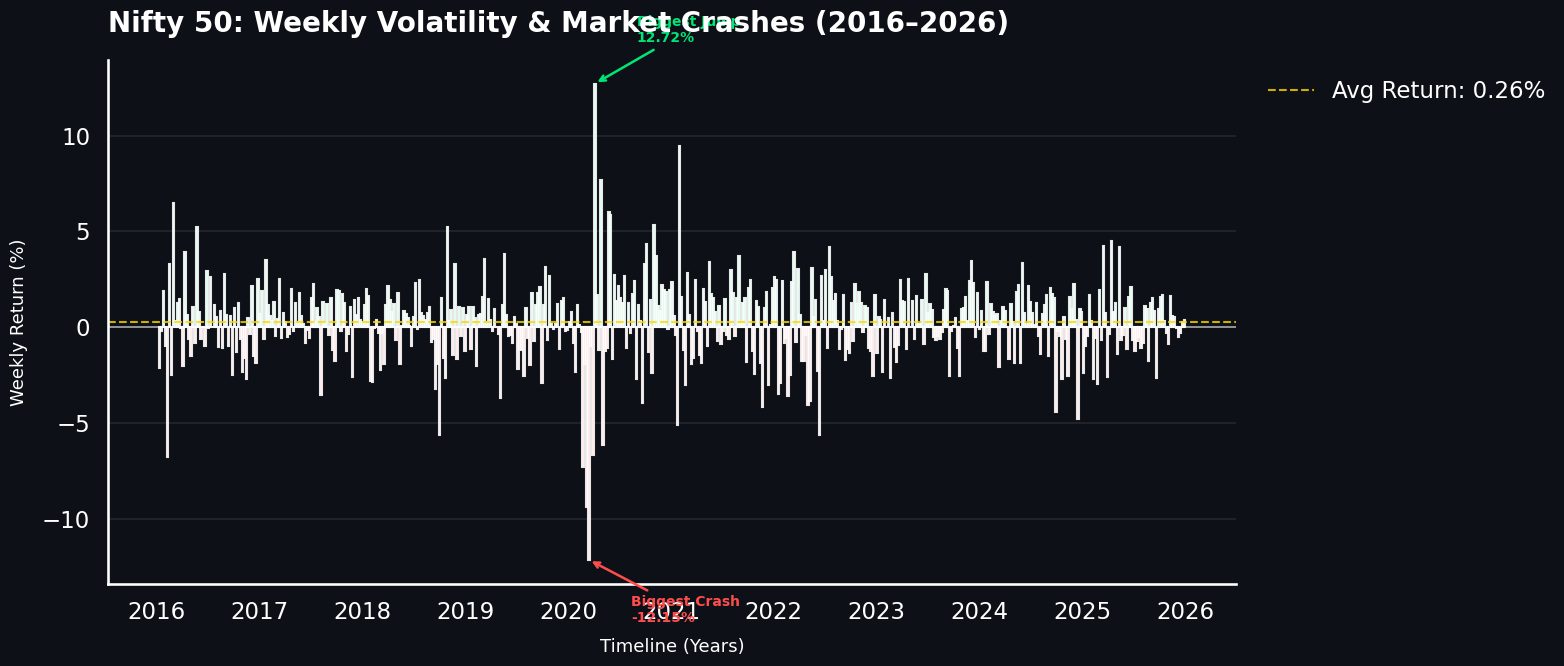

Chart saved: nifty50_price_trend_line.png


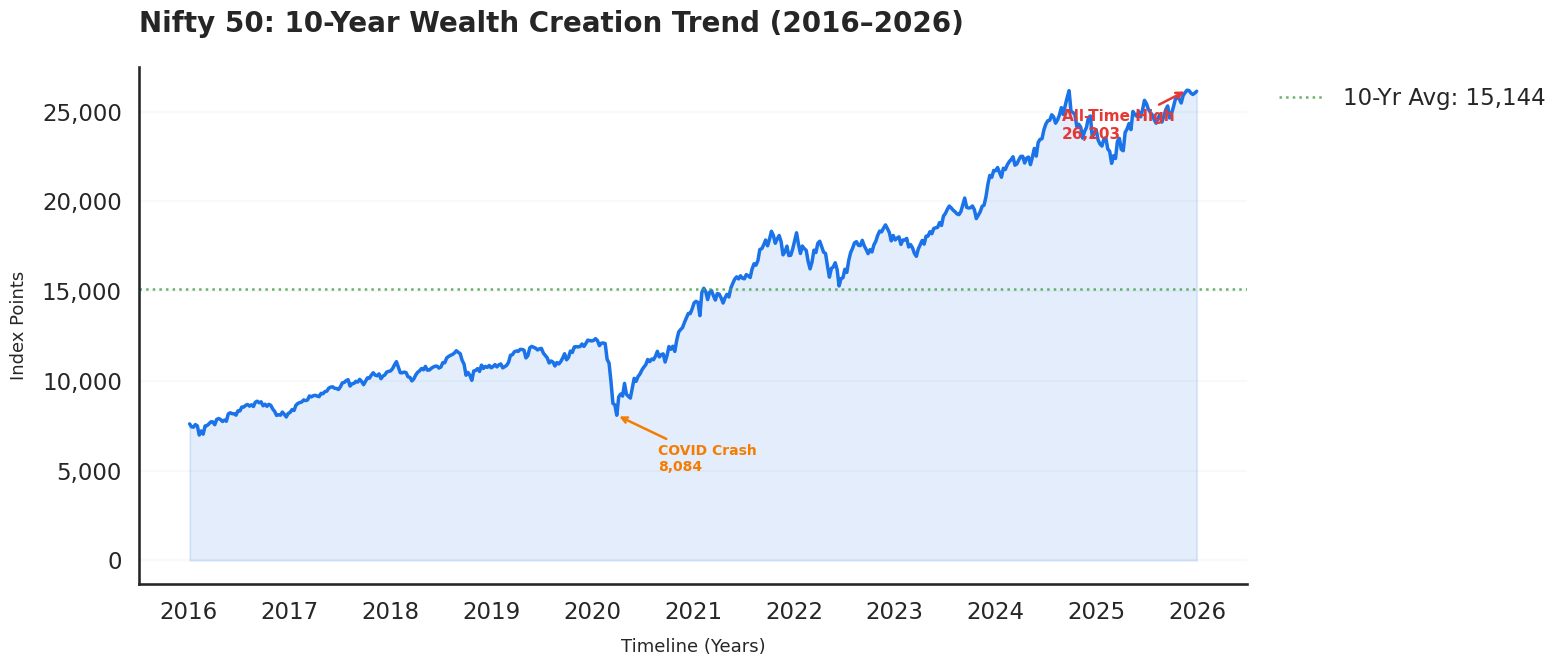

Chart saved: nifty50_returns_distribution_hist.png


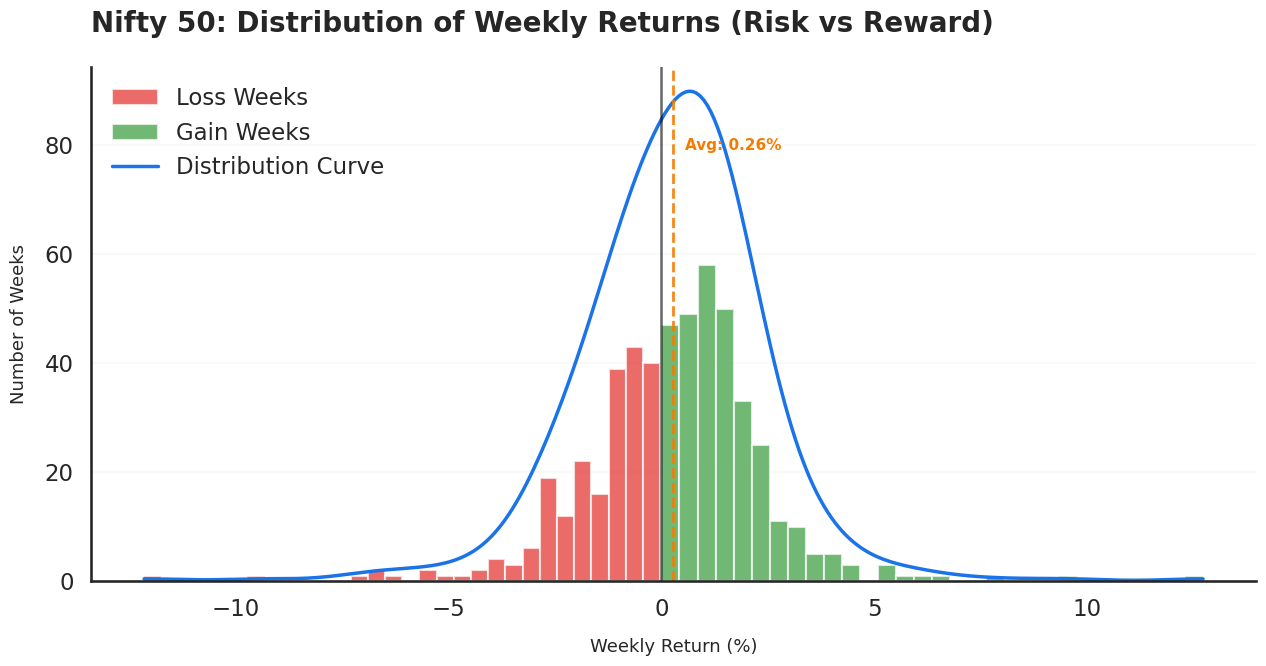

Chart saved: nifty50_yearly_avg_close_bar.png


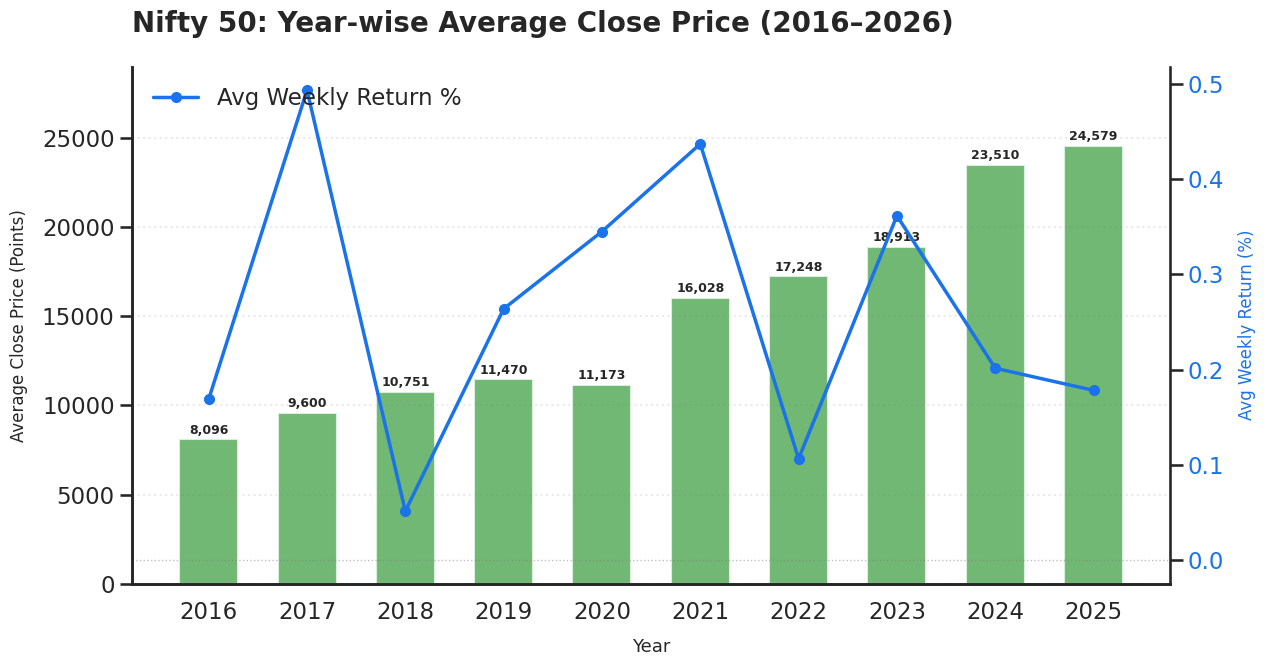

Chart saved: nifty50_moving_avg.png


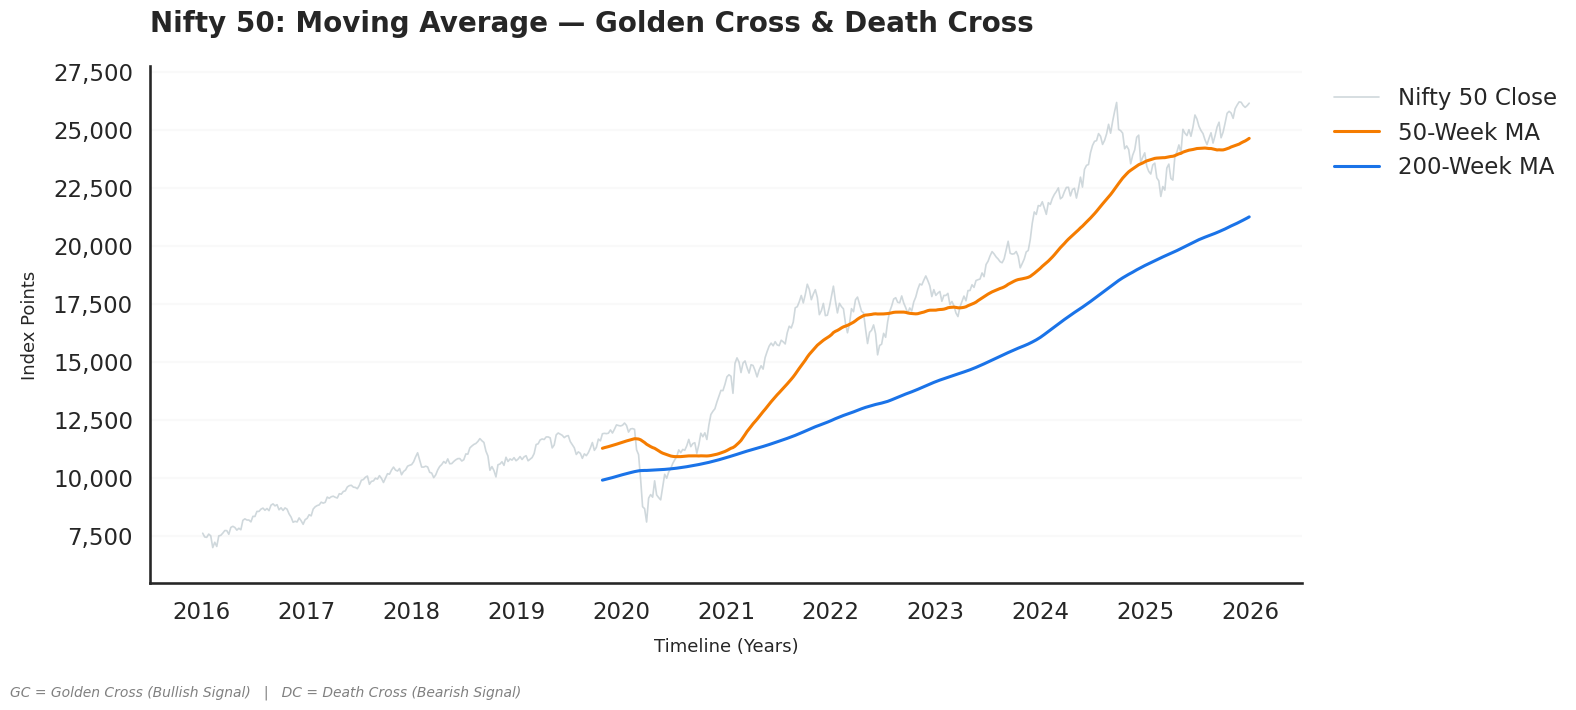

Chart saved: nifty50_monthly_seasonality.png


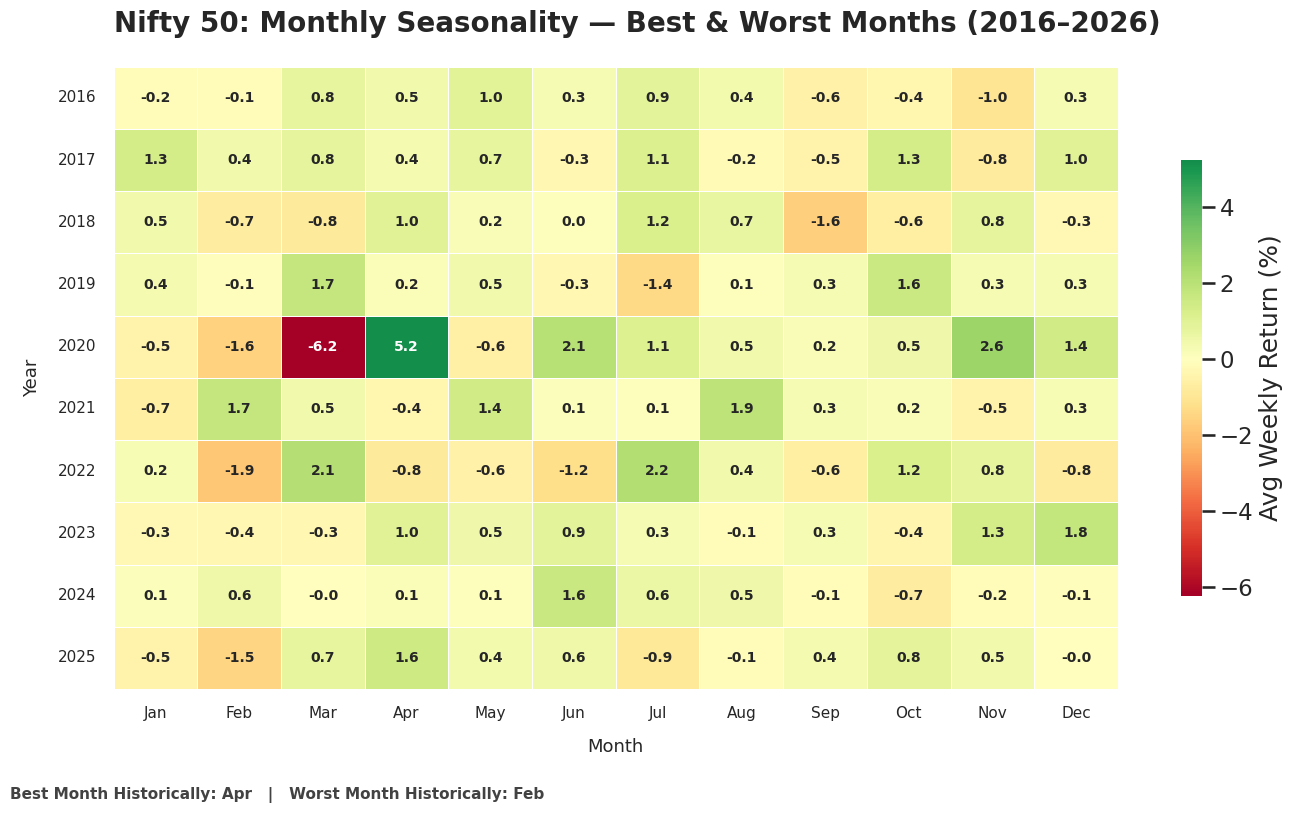

[DONE] All 6 charts saved successfully!


In [8]:
print("\n[PROCESS] Generating high-resolution insights...")

plot_pro_bar(sub_set.dropna(subset=['Weekly_Return_%']))
plot_pro_line(sub_set)
plot_pro_hist(sub_set.dropna(subset=['Weekly_Return_%']))
plot_pro_yearly_bar(yearly_summary)
plot_pro_moving_avg(sub_set)
plot_pro_seasonality(sub_set)

print("[DONE] All 6 charts saved successfully!")

# =================================================================
# SECTION I: TIMER END
# =================================================================

In [9]:
end = time.time()
print(f"-----Required Data Loading Time: {end - start:.4f} seconds------")

-----Required Data Loading Time: 15.6257 seconds------
